# Medical NER Dataset Preparation Pipeline for GLiNER2

This notebook implements a **reusable, configurable data preparation pipeline** that converts Label Studio annotated medical research papers into GLiNER2-compatible JSONL training data.

## Pipeline Overview

| Step | Description | Imbalance Strategy |
|------|-------------|-------------------|
| 1. Load & Parse | Parse Label Studio JSON exports | — |
| 2. Filter | Discard unlabeled items | — |
| 3. Analyze | Dataset statistics & imbalance assessment | — |
| 4. Chunk | Entity-aware text windowing | **Strategy #1** |
| 5. Negative Sampling | Controlled inclusion of entity-free chunks | **Strategy #2** |
| 6. Augmentation | Entity-centered context windows | **Strategy #3** |
| 7. Enrichment | Entity description injection | **Strategy #4** |
| 8. Convert | Transform to GLiNER2 JSONL format | — |
| 9. Split & Save | Train/val split + OOD eval processing | — |
| 10. Validate | GLiNER2 TrainingDataset validation | — |

## Key Design Decisions

- **Long texts (~26K chars avg)** are chunked into ~1500-char windows because GLiNER2's encoder has a limited context window (~512 tokens)
- **Entity-sparse data** (avg ~12 entities per 26K-char document) requires careful balancing of positive and negative examples
- **Single entity type** (`Dataset`) means inter-class imbalance is not an issue, but entity sparsity is
- **Pipeline is a reusable Python class** — change config once, re-run all cells

In [2]:
# Install dependencies
# Uncomment the line below when running on Google Colab
%pip install -q gliner2 "transformers<4.48" matplotlib seaborn

import json
import os
import random
from collections import Counter, defaultdict
from typing import List, Dict, Optional, Tuple

import matplotlib.pyplot as plt

print("Dependencies loaded.")

Note: you may need to restart the kernel to use updated packages.
Dependencies loaded.


## 1. Configuration

All pipeline parameters are defined here. **Modify this cell only** to adapt the pipeline to different datasets or experiments.

| Parameter | Description |
|-----------|-------------|
| `MAIN_DATASET_PATH` | Path to the main Label Studio JSON export (training data) |
| `OOD_DATASET_PATH` | Path to the out-of-distribution evaluation set |
| `OUTPUT_DIR` | Directory for all output files (JSONL, stats) |
| `CHUNK_SIZE` | Max characters per text chunk (~300-400 tokens) |
| `CHUNK_OVERLAP` | Overlap between consecutive chunks (chars) |
| `NEGATIVE_SAMPLE_RATIO` | Fraction of entity-free chunks to keep (0.0–1.0) |
| `AUGMENTATION_WINDOW_SIZE` | Smaller window for entity-centered augmentation |
| `AUGMENTATION_ENABLED` | Toggle augmentation on/off |
| `ENTITY_DESCRIPTIONS` | Dict mapping entity types to natural language descriptions |
| `TRAIN_RATIO` | Fraction of data for training |
| `VAL_RATIO` | Fraction of data for validation (early stopping / checkpoint selection) |
| `TEST_RATIO` | Fraction of data for in-distribution testing |
| `SEED` | Random seed for reproducibility |

In [3]:
# ============================================================
# CONFIGURATION — Modify these parameters for your experiment
# ============================================================

# --- Paths ---
# For Google Colab: mount drive first and use paths like '/content/drive/MyDrive/...'
# For local: use your local paths
MAIN_DATASET_PATH = "data-annotations.json"        # Main labeled dataset
OOD_DATASET_PATH = "44-eval-out-distri.json"       # Out-of-distribution eval set
OUTPUT_DIR = "./prepared_data"                      # Output directory for JSONL files

# --- Chunking ---
CHUNK_SIZE = 1500          # Characters per chunk (~300-400 tokens for DeBERTa)
CHUNK_OVERLAP = 300        # Overlap between consecutive chunks

# --- Imbalance Strategy #2: Negative Sampling ---
NEGATIVE_SAMPLE_RATIO = 0.15   # Keep 15% of entity-free chunks as negatives

# --- Imbalance Strategy #3: Entity-Centered Augmentation ---
AUGMENTATION_ENABLED = True
AUGMENTATION_WINDOW_SIZE = 800     # Smaller focused window around entities (chars)
AUGMENTATION_MAX_PER_DOC = 5       # Max augmented chunks per document

# --- Imbalance Strategy #4: Entity Description Enrichment ---
ENTITY_DESCRIPTIONS = {
    "Dataset": "Names of datasets, corpus, collections,  databases, benchmarks, or data collections used in scientific research"
}

# --- Train/Val/Test Split ---
TRAIN_RATIO = 0.75
VAL_RATIO = 0.10
TEST_RATIO = 0.15

# --- Reproducibility ---
SEED = 42

random.seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")
print(f"Chunk size: {CHUNK_SIZE} chars, overlap: {CHUNK_OVERLAP} chars")
print(f"Negative sample ratio: {NEGATIVE_SAMPLE_RATIO}")
print(f"Augmentation: {'ON' if AUGMENTATION_ENABLED else 'OFF'}")
print(f"Split: {TRAIN_RATIO:.0%} train / {VAL_RATIO:.0%} val / {TEST_RATIO:.0%} test")

Output directory: ./prepared_data
Chunk size: 1500 chars, overlap: 300 chars
Negative sample ratio: 0.15
Augmentation: ON
Split: 75% train / 10% val / 15% test


## 2. Data Preparation Pipeline Class

The entire pipeline is encapsulated in a single reusable class `DataPreparationPipeline`. All methods are stateless (pure functions) except for the orchestrator `run()` method.

### Why a class?
- **Reusability**: Instantiate with different configs for different experiments
- **Testability**: Each method can be tested independently
- **Reproducibility**: Configuration is explicit and logged

In [4]:
class DataPreparationPipeline:
    """
    Reusable pipeline to convert Label Studio NER annotations
    into GLiNER2 JSONL training data with imbalance handling.
    """

    def __init__(
        self,
        chunk_size: int = 1500,
        chunk_overlap: int = 300,
        negative_sample_ratio: float = 0.15,
        augmentation_enabled: bool = True,
        augmentation_window_size: int = 800,
        augmentation_max_per_doc: int = 5,
        entity_descriptions: Optional[Dict[str, str]] = None,
        seed: int = 42,
    ):
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.negative_sample_ratio = negative_sample_ratio
        self.augmentation_enabled = augmentation_enabled
        self.augmentation_window_size = augmentation_window_size
        self.augmentation_max_per_doc = augmentation_max_per_doc
        self.entity_descriptions = entity_descriptions or {}
        self.seed = seed
        self.rng = random.Random(seed)

    @staticmethod
    def _normalize_text(text: str) -> str:
        """Replace newlines/tabs with spaces and collapse multiple spaces."""
        import re
        return re.sub(r'\s+', ' ', text).strip()

    # ------------------------------------------------------------------
    # Step 1: Parse Label Studio JSON
    # ------------------------------------------------------------------
    def parse_label_studio_json(self, filepath: str) -> List[Dict]:
        """
        Parse a Label Studio JSON export into a list of documents.
        Normalizes document text and entity spans (replaces newlines with spaces).

        Returns list of dicts:
            {'text': str, 'entities': [{'start','end','text','label'}], 'is_labeled': bool}
        """
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

        parsed = []
        for item in data:
            raw_text = (item.get("data") or {}).get("text", "")
            if not raw_text:
                continue

            # Normalize the full document text: replace newlines/tabs with spaces
            text = raw_text.replace('\r\n', ' ').replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

            # Build a mapping from old char positions to new positions
            # Since we only replace single chars with single chars (same length), offsets stay the same
            entities = []
            for annot in item.get("annotations") or []:
                for r in annot.get("result") or []:
                    value = r.get("value") or {}
                    start = value.get("start")
                    end = value.get("end")
                    labels = value.get("labels") or []
                    if start is not None and end is not None:
                        # Use the actual text at offsets (after normalization) as canonical
                        entity_text = text[start:end].strip()
                        if not entity_text:
                            continue
                        # Adjust offsets to match stripped text
                        offset = text[start:end].index(entity_text) if entity_text in text[start:end] else 0
                        adj_start = start + offset
                        adj_end = adj_start + len(entity_text)
                        for label in labels:
                            entities.append(
                                {"start": adj_start, "end": adj_end, "text": entity_text, "label": label}
                            )

            parsed.append({"text": text, "entities": entities, "is_labeled": len(entities) > 0})

        return parsed

    # ------------------------------------------------------------------
    # Step 2: Filter unlabeled documents
    # ------------------------------------------------------------------
    def filter_labeled(self, documents: List[Dict]) -> Tuple[List[Dict], int]:
        """Remove documents with no annotations. Returns (filtered_docs, num_removed)."""
        labeled = [doc for doc in documents if doc["is_labeled"]]
        return labeled, len(documents) - len(labeled)

    # ------------------------------------------------------------------
    # Step 3: Analyze dataset
    # ------------------------------------------------------------------
    def analyze_dataset(self, documents: List[Dict]) -> Dict:
        """Compute dataset statistics for imbalance assessment."""
        label_counter = Counter()
        entities_per_doc = []
        text_lengths = []
        entity_text_lengths = []

        for doc in documents:
            text_lengths.append(len(doc["text"]))
            entities_per_doc.append(len(doc["entities"]))
            for ent in doc["entities"]:
                label_counter[ent["label"]] += 1
                entity_text_lengths.append(len(ent["text"]))

        stats = {
            "num_documents": len(documents),
            "label_distribution": dict(label_counter),
            "total_entities": sum(label_counter.values()),
            "entities_per_doc": {
                "mean": sum(entities_per_doc) / max(len(entities_per_doc), 1),
                "min": min(entities_per_doc) if entities_per_doc else 0,
                "max": max(entities_per_doc) if entities_per_doc else 0,
                "median": sorted(entities_per_doc)[len(entities_per_doc) // 2] if entities_per_doc else 0,
            },
            "text_length": {
                "mean": sum(text_lengths) / max(len(text_lengths), 1),
                "min": min(text_lengths) if text_lengths else 0,
                "max": max(text_lengths) if text_lengths else 0,
            },
            "entity_text_length": {
                "mean": sum(entity_text_lengths) / max(len(entity_text_lengths), 1),
                "min": min(entity_text_lengths) if entity_text_lengths else 0,
                "max": max(entity_text_lengths) if entity_text_lengths else 0,
            },
            "_raw_entities_per_doc": entities_per_doc,
            "_raw_text_lengths": text_lengths,
        }
        return stats

    # ------------------------------------------------------------------
    # Step 4: Entity-Aware Text Chunking (Imbalance Strategy #1)
    # ------------------------------------------------------------------
    def chunk_document(self, doc: Dict) -> List[Dict]:
        """
        Split a long document into overlapping chunks.
        Maps entity spans to their new positions within each chunk.
        Entities spanning chunk boundaries are discarded.

        Returns list of dicts:
            {'text': str, 'entities': [...], 'has_entities': bool, 'source': 'chunk'}
        """
        text = doc["text"]
        entities = doc["entities"]
        text_len = len(text)
        chunks = []
        start = 0

        while start < text_len:
            end = min(start + self.chunk_size, text_len)

            # Try to break at a sentence boundary near the end
            if end < text_len:
                search_start = max(start, end - 200)
                for sep in [". ", ".\n", "\n\n", "\n", " "]:
                    last_sep = text[search_start:end].rfind(sep)
                    if last_sep != -1:
                        end = search_start + last_sep + len(sep)
                        break

            chunk_text = text[start:end]

            # Map entities to this chunk (only fully contained entities)
            chunk_entities = []
            for ent in entities:
                if ent["start"] >= start and ent["end"] <= end:
                    chunk_entities.append({
                        "start": ent["start"] - start,
                        "end": ent["end"] - start,
                        "text": ent["text"],
                        "label": ent["label"],
                    })

            chunks.append({
                "text": chunk_text,
                "entities": chunk_entities,
                "has_entities": len(chunk_entities) > 0,
                "source": "chunk",
            })

            if end >= text_len:
                break
            start = end - self.chunk_overlap

        return chunks

    def chunk_all_documents(self, documents: List[Dict]) -> List[Dict]:
        """Chunk all documents and return flat list of chunks."""
        all_chunks = []
        for doc in documents:
            all_chunks.extend(self.chunk_document(doc))
        return all_chunks

    # ------------------------------------------------------------------
    # Step 5: Negative Sampling (Imbalance Strategy #2)
    # ------------------------------------------------------------------
    def apply_negative_sampling(self, chunks: List[Dict]) -> Tuple[List[Dict], Dict]:
        """
        Keep all entity-containing chunks.
        Subsample entity-free chunks at `negative_sample_ratio`.

        Returns (balanced_chunks, sampling_stats).
        """
        positive = [c for c in chunks if c["has_entities"]]
        negative = [c for c in chunks if not c["has_entities"]]

        n_neg_keep = max(1, int(len(negative) * self.negative_sample_ratio))
        sampled_neg = self.rng.sample(negative, min(n_neg_keep, len(negative)))

        balanced = positive + sampled_neg
        self.rng.shuffle(balanced)

        stats = {
            "positive_chunks": len(positive),
            "total_negative_chunks": len(negative),
            "sampled_negative_chunks": len(sampled_neg),
            "total_after_sampling": len(balanced),
        }
        return balanced, stats

    # ------------------------------------------------------------------
    # Step 6: Entity-Centered Augmentation (Imbalance Strategy #3)
    # ------------------------------------------------------------------
    def create_entity_centered_chunks(self, doc: Dict) -> List[Dict]:
        """
        Create smaller, focused chunks centered on entity mentions.
        This oversamples entity-rich regions as a form of augmentation.
        """
        if not doc["entities"]:
            return []

        text = doc["text"]
        text_len = len(text)
        half_window = self.augmentation_window_size // 2
        aug_chunks = []
        used_centers = set()

        # Shuffle entities so different runs can pick different ones
        shuffled_entities = list(doc["entities"])
        self.rng.shuffle(shuffled_entities)

        for ent in shuffled_entities:
            if len(aug_chunks) >= self.augmentation_max_per_doc:
                break

            center = (ent["start"] + ent["end"]) // 2

            # Skip if too close to an already-used center (avoid near-duplicates)
            if any(abs(center - uc) < half_window // 2 for uc in used_centers):
                continue
            used_centers.add(center)

            win_start = max(0, center - half_window)
            win_end = min(text_len, center + half_window)

            # Try to align to sentence boundaries
            for sep in [". ", "\n"]:
                idx = text[win_start:min(win_start + 100, center)].find(sep)
                if idx != -1:
                    win_start = win_start + idx + len(sep)
                    break

            chunk_text = text[win_start:win_end]

            # Map all entities within this window
            chunk_entities = []
            for e in doc["entities"]:
                if e["start"] >= win_start and e["end"] <= win_end:
                    chunk_entities.append({
                        "start": e["start"] - win_start,
                        "end": e["end"] - win_start,
                        "text": e["text"],
                        "label": e["label"],
                    })

            if chunk_entities:  # Only add if at least one entity is captured
                aug_chunks.append({
                    "text": chunk_text,
                    "entities": chunk_entities,
                    "has_entities": True,
                    "source": "augmentation",
                })

        return aug_chunks

    def augment_all_documents(self, documents: List[Dict]) -> List[Dict]:
        """Create entity-centered augmentation chunks for all documents."""
        aug_chunks = []
        for doc in documents:
            aug_chunks.extend(self.create_entity_centered_chunks(doc))
        return aug_chunks

    # ------------------------------------------------------------------
    # Step 7 & 8: Convert to GLiNER2 JSONL Format (with Strategy #4)
    # ------------------------------------------------------------------
    def chunk_to_gliner2(self, chunk: Dict) -> Dict:
        """
        Convert a chunk to GLiNER2 JSONL format.
        Applies entity description enrichment (Strategy #4).
        """
        # Group entities by type, deduplicate
        entities_by_type: Dict[str, List[str]] = defaultdict(list)
        for ent in chunk["entities"]:
            if ent["text"] not in entities_by_type[ent["label"]]:
                entities_by_type[ent["label"]].append(ent["text"])

        # For negative examples, include empty entity lists for known types
        if not entities_by_type:
            for entity_type in self.entity_descriptions:
                entities_by_type[entity_type] = []

        output: Dict = {"entities": dict(entities_by_type)}

        # Strategy #4: Entity description enrichment
        if self.entity_descriptions:
            relevant_descs = {
                k: v for k, v in self.entity_descriptions.items()
                if k in entities_by_type
            }
            if relevant_descs:
                output["entity_descriptions"] = relevant_descs

        return {"input": chunk["text"], "output": output}

    def convert_all_to_gliner2(self, chunks: List[Dict]) -> List[Dict]:
        """Convert all chunks to GLiNER2 JSONL format."""
        return [self.chunk_to_gliner2(c) for c in chunks]

    # ------------------------------------------------------------------
    # Step 9: Train/Val Split
    # ------------------------------------------------------------------
    def split_data(
        self, examples: List[Dict], train_ratio: float, val_ratio: float
    ) -> Tuple[List[Dict], List[Dict], List[Dict]]:
        """Shuffle and split data into train, validation, and test sets.
        Test set is the remainder after train + val."""
        shuffled = list(examples)
        self.rng.shuffle(shuffled)

        n_train = int(len(shuffled) * train_ratio)
        n_val = int(len(shuffled) * val_ratio)
        train = shuffled[:n_train]
        val = shuffled[n_train:n_train + n_val]
        test = shuffled[n_train + n_val:]
        return train, val, test

    # ------------------------------------------------------------------
    # I/O Helpers
    # ------------------------------------------------------------------
    @staticmethod
    def save_jsonl(data: List[Dict], filepath: str):
        """Save list of dicts as JSONL file."""
        with open(filepath, "w", encoding="utf-8") as f:
            for item in data:
                f.write(json.dumps(item, ensure_ascii=False) + "\n")
        print(f"  Saved {len(data)} examples to {filepath}")

    @staticmethod
    def load_jsonl(filepath: str) -> List[Dict]:
        """Load JSONL file into list of dicts."""
        data = []
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if line:
                    data.append(json.loads(line))
        return data


# Instantiate pipeline with configuration
pipeline = DataPreparationPipeline(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    negative_sample_ratio=NEGATIVE_SAMPLE_RATIO,
    augmentation_enabled=AUGMENTATION_ENABLED,
    augmentation_window_size=AUGMENTATION_WINDOW_SIZE,
    augmentation_max_per_doc=AUGMENTATION_MAX_PER_DOC,
    entity_descriptions=ENTITY_DESCRIPTIONS,
    seed=SEED,
)

print("Pipeline instantiated.")

Pipeline instantiated.


## 3. Load & Parse Label Studio Data

The datasets are in **Label Studio JSON** format. Each item contains:
- `data.text` — the full document text
- `annotations[].result[]` — list of annotation results, each with:
  - `value.start` / `value.end` — character offsets
  - `value.text` — the annotated span text
  - `value.labels` — list of entity type labels

In [5]:
# Load both datasets
main_docs = pipeline.parse_label_studio_json(MAIN_DATASET_PATH)
ood_docs = pipeline.parse_label_studio_json(OOD_DATASET_PATH)

print(f"Main dataset: {len(main_docs)} documents")
print(f"  Labeled: {sum(1 for d in main_docs if d['is_labeled'])}")
print(f"  Unlabeled: {sum(1 for d in main_docs if not d['is_labeled'])}")
print(f"\nOOD eval set: {len(ood_docs)} documents")
print(f"  Labeled: {sum(1 for d in ood_docs if d['is_labeled'])}")

Main dataset: 954 documents
  Labeled: 542
  Unlabeled: 412

OOD eval set: 44 documents
  Labeled: 44


## 4. Filter Unlabeled Data

The main dataset contains documents that were **not annotated** (no entity labels). These are discarded because:
- We cannot know if they genuinely contain no entities or simply weren't labeled
- Including them as negative examples would introduce label noise

In [6]:
main_docs_labeled, n_removed = pipeline.filter_labeled(main_docs)

print(f"Filtered out {n_removed} unlabeled documents.")
print(f"Remaining labeled documents: {len(main_docs_labeled)}")

Filtered out 412 unlabeled documents.
Remaining labeled documents: 542


## 5. Dataset Analysis & Imbalance Assessment

Before applying any balancing strategies, we analyze the raw dataset to understand:
1. **Entity distribution** — how many entities of each type
2. **Text length distribution** — how long are the documents (relevant for chunking)
3. **Entities per document** — how sparse are the annotations
4. **Entity density** — entities per 1000 characters (key imbalance metric)

In [7]:
stats = pipeline.analyze_dataset(main_docs_labeled)

print("=" * 60)
print("DATASET STATISTICS (before chunking)")
print("=" * 60)
print(f"Documents:        {stats['num_documents']}")
print(f"Total entities:   {stats['total_entities']}")
print(f"Label types:      {stats['label_distribution']}")
print(f"\nEntities per document:")
print(f"  Mean:   {stats['entities_per_doc']['mean']:.1f}")
print(f"  Median: {stats['entities_per_doc']['median']}")
print(f"  Min:    {stats['entities_per_doc']['min']}")
print(f"  Max:    {stats['entities_per_doc']['max']}")
print(f"\nText length (chars):")
print(f"  Mean: {stats['text_length']['mean']:,.0f}")
print(f"  Min:  {stats['text_length']['min']:,}")
print(f"  Max:  {stats['text_length']['max']:,}")
print(f"\nEntity text length (chars):")
print(f"  Mean: {stats['entity_text_length']['mean']:.1f}")
print(f"  Min:  {stats['entity_text_length']['min']}")
print(f"  Max:  {stats['entity_text_length']['max']}")

# Density metric
avg_density = stats['total_entities'] / (stats['text_length']['mean'] * stats['num_documents'] / 1000)
print(f"\nEntity density: {avg_density:.3f} entities per 1000 chars")
print(f"  → This means on average only ~{avg_density * CHUNK_SIZE / 1000:.1f} entities per {CHUNK_SIZE}-char chunk")
print(f"  → Most chunks will have 0-2 entities → SPARSE (imbalanced)")

DATASET STATISTICS (before chunking)
Documents:        542
Total entities:   6353
Label types:      {'Dataset': 6353}

Entities per document:
  Mean:   11.7
  Median: 7
  Min:    1
  Max:    109

Text length (chars):
  Mean: 26,383
  Min:  4,065
  Max:  299,869

Entity text length (chars):
  Mean: 13.9
  Min:  2
  Max:  194

Entity density: 0.444 entities per 1000 chars
  → This means on average only ~0.7 entities per 1500-char chunk
  → Most chunks will have 0-2 entities → SPARSE (imbalanced)


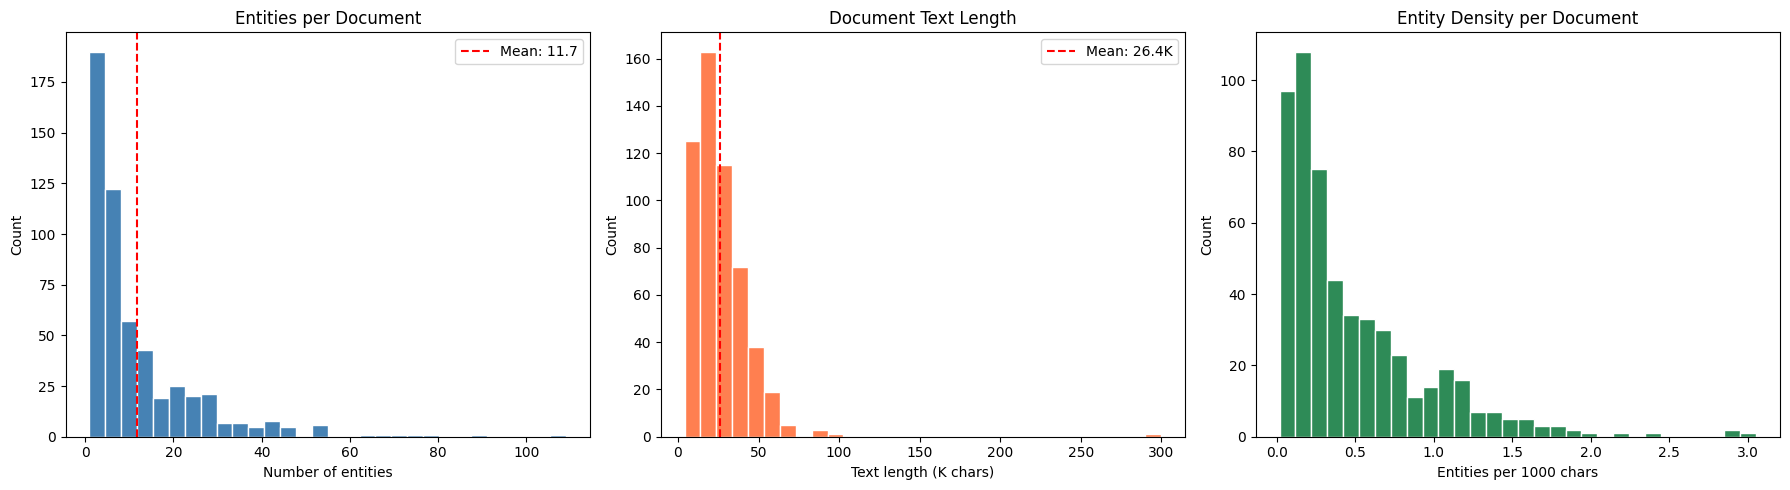

Saved analysis plot.


In [8]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Entities per document
axes[0].hist(stats["_raw_entities_per_doc"], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(stats["entities_per_doc"]["mean"], color="red", linestyle="--", label=f"Mean: {stats['entities_per_doc']['mean']:.1f}")
axes[0].set_title("Entities per Document")
axes[0].set_xlabel("Number of entities")
axes[0].set_ylabel("Count")
axes[0].legend()

# 2. Text length distribution
axes[1].hist([l / 1000 for l in stats["_raw_text_lengths"]], bins=30, color="coral", edgecolor="white")
axes[1].axvline(stats["text_length"]["mean"] / 1000, color="red", linestyle="--", label=f"Mean: {stats['text_length']['mean']/1000:.1f}K")
axes[1].set_title("Document Text Length")
axes[1].set_xlabel("Text length (K chars)")
axes[1].set_ylabel("Count")
axes[1].legend()

# 3. Entity density per doc
densities = [
    (e / (l / 1000)) if l > 0 else 0
    for e, l in zip(stats["_raw_entities_per_doc"], stats["_raw_text_lengths"])
]
axes[2].hist(densities, bins=30, color="seagreen", edgecolor="white")
axes[2].set_title("Entity Density per Document")
axes[2].set_xlabel("Entities per 1000 chars")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "dataset_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved analysis plot.")

## 6. Strategy #1 — Entity-Aware Text Chunking

**Problem**: Documents average ~26K characters, but GLiNER2's DeBERTa encoder handles ~512 tokens (~1500 chars).

**Solution**: Sliding window chunking with:
- **Sentence-boundary alignment** — avoids splitting mid-sentence
- **Configurable overlap** — prevents entities near chunk boundaries from being lost
- **Entity mapping** — each entity is mapped to its new position in the chunk; entities split across boundaries are discarded

In [9]:
all_chunks = pipeline.chunk_all_documents(main_docs_labeled)

n_pos = sum(1 for c in all_chunks if c["has_entities"])
n_neg = sum(1 for c in all_chunks if not c["has_entities"])
total_ents = sum(len(c["entities"]) for c in all_chunks)

print(f"Total chunks: {len(all_chunks)}")
print(f"  With entities:    {n_pos} ({n_pos/len(all_chunks)*100:.1f}%)")
print(f"  Without entities: {n_neg} ({n_neg/len(all_chunks)*100:.1f}%)")
print(f"  Total entity mentions mapped: {total_ents}")
print(f"\n  → Before chunking: {stats['total_entities']} entities")
print(f"  → After chunking:  {total_ents} entities (some duplicated via overlap, some lost at boundaries)")

Total chunks: 12730
  With entities:    3391 (26.6%)
  Without entities: 9339 (73.4%)
  Total entity mentions mapped: 7948

  → Before chunking: 6353 entities
  → After chunking:  7948 entities (some duplicated via overlap, some lost at boundaries)


## 7. Strategy #2 — Controlled Negative Sampling

**Problem**: After chunking, most chunks have **no entities** (entity-sparse data). Training on all of them would overwhelm the model with negative examples.

**Solution**: Keep ALL entity-containing chunks, but **subsample** entity-free chunks at a configurable ratio.

- A ratio of `0.15` means we keep 15% of entity-free chunks
- This teaches the model when **not** to extract, without drowning entity signals
- The ratio is a key hyperparameter — too low → model hallucinates entities; too high → model misses entities

In [10]:
balanced_chunks, neg_stats = pipeline.apply_negative_sampling(all_chunks)

print(f"Negative Sampling Results:")
print(f"  Positive chunks (kept all):     {neg_stats['positive_chunks']}")
print(f"  Negative chunks (before):       {neg_stats['total_negative_chunks']}")
print(f"  Negative chunks (after {NEGATIVE_SAMPLE_RATIO:.0%}):  {neg_stats['sampled_negative_chunks']}")
print(f"  Total after balancing:          {neg_stats['total_after_sampling']}")

pos_pct = neg_stats['positive_chunks'] / neg_stats['total_after_sampling'] * 100
print(f"\n  Positive/Negative ratio: {pos_pct:.1f}% / {100-pos_pct:.1f}%")

Negative Sampling Results:
  Positive chunks (kept all):     3391
  Negative chunks (before):       9339
  Negative chunks (after 15%):  1400
  Total after balancing:          4791

  Positive/Negative ratio: 70.8% / 29.2%


## 8. Strategy #3 — Entity-Centered Augmentation

**Problem**: Even after chunking, some entities may appear in large chunks with lots of surrounding non-entity text, diluting the entity signal.

**Solution**: Create **additional smaller windows** (800 chars) centered directly on entity mentions. This:
- **Oversamples entity-rich regions** — a form of targeted augmentation
- **Provides varied context** — the model sees entities with different surrounding contexts
- **Controlled via `max_per_doc`** — prevents excessive duplication

In [11]:
if AUGMENTATION_ENABLED:
    aug_chunks = pipeline.augment_all_documents(main_docs_labeled)
    print(f"Entity-centered augmentation chunks created: {len(aug_chunks)}")
    print(f"  Avg entities per aug chunk: {sum(len(c['entities']) for c in aug_chunks)/max(len(aug_chunks),1):.2f}")

    # Add augmentation chunks to balanced set
    combined_chunks = balanced_chunks + aug_chunks
    pipeline.rng.shuffle(combined_chunks)

    print(f"\nTotal chunks after augmentation: {len(combined_chunks)}")
    print(f"  From regular chunking: {len(balanced_chunks)}")
    print(f"  From augmentation:     {len(aug_chunks)}")
else:
    combined_chunks = balanced_chunks
    print("Augmentation disabled. Using balanced chunks only.")
    print(f"Total chunks: {len(combined_chunks)}")

Entity-centered augmentation chunks created: 2054
  Avg entities per aug chunk: 2.18

Total chunks after augmentation: 6845
  From regular chunking: 4791
  From augmentation:     2054


## 9. Strategy #4 — Entity Description Enrichment + Convert to GLiNER2 Format

**Problem**: A single entity type `"Dataset"` is vague — the model may confuse it with other named entities.

**Solution**: GLiNER2 supports `entity_descriptions` — natural language descriptions of what each entity type means. This is injected into every training example.

```json
"entity_descriptions": {
    "Dataset": "Names of datasets, databases, benchmarks, or data collections used in scientific research"
}
```

### GLiNER2 JSONL Format
Each line in the output JSONL file follows this structure:
```json
{"input": "text...", "output": {"entities": {"Dataset": ["name1", "name2"]}, "entity_descriptions": {"Dataset": "..."}}}
```

In [12]:
gliner2_examples = pipeline.convert_all_to_gliner2(combined_chunks)

print(f"Converted {len(gliner2_examples)} examples to GLiNER2 JSONL format.")

# Show a sample
print("\n--- Sample positive example ---")
for ex in gliner2_examples:
    if any(len(v) > 0 for v in ex["output"]["entities"].values()):
        print(json.dumps({
            "input": ex["input"][:200] + "...",
            "output": ex["output"]
        }, indent=2))
        break

print("\n--- Sample negative example ---")
for ex in gliner2_examples:
    if all(len(v) == 0 for v in ex["output"]["entities"].values()):
        print(json.dumps({
            "input": ex["input"][:200] + "...",
            "output": ex["output"]
        }, indent=2))
        break

Converted 6845 examples to GLiNER2 JSONL format.

--- Sample positive example ---
{
  "input": "Memory Efficient 3D U-Net with Reversible Mobile Inverted Bottlenecks for Brain Tumor Segmentation We propose combining memory saving techniques with traditional U-Net architectures to increase the co...",
  "output": {
    "entities": {
      "Dataset": [
        "Brain Tumor Segmentation (BraTS) challenge",
        "BraTS challenge"
      ]
    },
    "entity_descriptions": {
      "Dataset": "Names of datasets, corpus, collections,  databases, benchmarks, or data collections used in scientific research"
    }
  }
}

--- Sample negative example ---
{
  "input": ". C. Discussions of Latencies within Motions Similar to our discussions in the main manuscript, we now discuss how agents handle trajectory-changing events when planning their future motions in the fo...",
  "output": {
    "entities": {
      "Dataset": []
    },
    "entity_descriptions": {
      "Dataset": "Names of datasets, co

## 10. Train/Validation/Test Split & Save

Data is shuffled and split into:
- **Training set** (75%) — used for model training
- **Validation set** (10%) — used for early stopping and checkpoint selection during training
- **Test set** (15%) — held-out in-distribution test set for final evaluation

The split is at the **chunk level** (not document level), since chunks from the same document can appear in both sets. For stricter evaluation, you could modify the pipeline to split at document level before chunking.

In [13]:
train_data, val_data, test_data = pipeline.split_data(gliner2_examples, TRAIN_RATIO, VAL_RATIO)

train_path = os.path.join(OUTPUT_DIR, "train.jsonl")
val_path = os.path.join(OUTPUT_DIR, "val.jsonl")
test_path = os.path.join(OUTPUT_DIR, "test.jsonl")

pipeline.save_jsonl(train_data, train_path)
pipeline.save_jsonl(val_data, val_path)
pipeline.save_jsonl(test_data, test_path)

# Stats
def _count_pos(data):
    return sum(1 for ex in data if any(len(v) > 0 for v in ex["output"]["entities"].values()))

train_pos = _count_pos(train_data)
val_pos = _count_pos(val_data)
test_pos = _count_pos(test_data)

print(f"\nTrain set: {len(train_data)} examples ({train_pos} positive, {len(train_data)-train_pos} negative)")
print(f"Val set:   {len(val_data)} examples ({val_pos} positive, {len(val_data)-val_pos} negative)")
print(f"Test set:  {len(test_data)} examples ({test_pos} positive, {len(test_data)-test_pos} negative)")

  Saved 5133 examples to ./prepared_data/train.jsonl
  Saved 684 examples to ./prepared_data/val.jsonl
  Saved 1028 examples to ./prepared_data/test.jsonl

Train set: 5133 examples (4060 positive, 1073 negative)
Val set:   684 examples (562 positive, 122 negative)
Test set:  1028 examples (823 positive, 205 negative)


## 11. Process Out-of-Distribution Evaluation Set

The OOD set (`44-eval-out-distri.json`) is processed with the **same chunking pipeline** but:
- **No negative sampling** — keep all chunks for complete evaluation
- **No augmentation** — evaluate on natural distribution
- **No split** — entire set used for evaluation

In [14]:
# All OOD docs are labeled (verified earlier)
ood_docs_labeled, _ = pipeline.filter_labeled(ood_docs)

# Chunk (no negative sampling, no augmentation)
ood_chunks = pipeline.chunk_all_documents(ood_docs_labeled)

# Keep ALL chunks (positive + negative) for fair evaluation
ood_gliner2 = pipeline.convert_all_to_gliner2(ood_chunks)

ood_path = os.path.join(OUTPUT_DIR, "eval_ood.jsonl")
pipeline.save_jsonl(ood_gliner2, ood_path)

ood_pos = sum(1 for ex in ood_gliner2 if any(len(v) > 0 for v in ex["output"]["entities"].values()))
print(f"\nOOD evaluation set: {len(ood_gliner2)} chunks ({ood_pos} with entities, {len(ood_gliner2)-ood_pos} without)")

  Saved 1129 examples to ./prepared_data/eval_ood.jsonl

OOD evaluation set: 1129 chunks (246 with entities, 883 without)


## 12. Validate with GLiNER2 TrainingDataset

GLiNER2 provides built-in dataset validation to catch formatting errors before training. This checks:
- JSON structure correctness
- Required fields present
- Entity mentions exist in input text (strict mode)
- At least one task per example

In [16]:
try:
    from gliner2.training.data import TrainingDataset

    for name, path in [("Training", train_path), ("Validation", val_path), ("OOD eval", ood_path)]:
        print(f"Validating {name} set...")
        ds = TrainingDataset.load(path)
        ds.validate(raise_on_error=False)
        if hasattr(ds, 'print_stats'):
            ds.print_stats()
        else:
            print(f"  {name}: {len(ds)} examples loaded ✓")
        print()

    print("✓ All datasets validated successfully!")

except ImportError:
    print("gliner2 not installed. Skipping GLiNER2 validation.")
    print("Install with: pip install gliner2")
    print("\nManual validation (checking JSONL structure):")
    for name, path in [("train", train_path), ("val", val_path), ("ood", ood_path)]:
        data = pipeline.load_jsonl(path)
        errors = 0
        for i, ex in enumerate(data):
            if "input" not in ex or "output" not in ex:
                print(f"  {name} example {i}: missing 'input' or 'output'")
                errors += 1
            elif "entities" not in ex.get("output", {}):
                print(f"  {name} example {i}: missing 'entities' in output")
                errors += 1
        print(f"  {name}: {len(data)} examples, {errors} errors")

Validating Training set...
Loaded 5133 examples from prepared_data/train.jsonl

GLiNER2 Training Dataset Statistics
Total examples: 5133

Text lengths: min=338, max=1500, mean=1225.7

Task Distribution:
  entities_only: 5133 (100.0%)

Entity Types (7450 total mentions):
  Dataset: 7450


Validating Validation set...
Loaded 684 examples from prepared_data/val.jsonl

GLiNER2 Training Dataset Statistics
Total examples: 684

Text lengths: min=325, max=1500, mean=1187.0

Task Distribution:
  entities_only: 684 (100.0%)

Entity Types (1077 total mentions):
  Dataset: 1077


Validating OOD eval set...
Loaded 1129 examples from prepared_data/eval_ood.jsonl

GLiNER2 Training Dataset Statistics
Total examples: 1129

Text lengths: min=469, max=1500, mean=1409.6

Task Distribution:
  entities_only: 1129 (100.0%)

Entity Types (438 total mentions):
  Dataset: 438


✓ All datasets validated successfully!


## 13. Final Summary

Review the complete pipeline output and generated files.

In [17]:
print("=" * 60)
print("DATA PREPARATION PIPELINE — SUMMARY")
print("=" * 60)
print(f"\n📁 Input:")
print(f"  Main dataset:  {MAIN_DATASET_PATH} ({len(main_docs)} docs, {len(main_docs_labeled)} labeled)")
print(f"  OOD eval set:  {OOD_DATASET_PATH} ({len(ood_docs)} docs)")
print(f"\n⚙️  Pipeline Configuration:")
print(f"  Chunk size:           {CHUNK_SIZE} chars")
print(f"  Chunk overlap:        {CHUNK_OVERLAP} chars")
print(f"  Negative sample ratio: {NEGATIVE_SAMPLE_RATIO}")
print(f"  Augmentation:         {'ON' if AUGMENTATION_ENABLED else 'OFF'}")
print(f"  Entity descriptions:  {list(ENTITY_DESCRIPTIONS.keys())}")
print(f"\n📊 Imbalance Strategies Applied:")
print(f"  #1 Entity-aware chunking:    {len(all_chunks)} chunks from {len(main_docs_labeled)} docs")
print(f"  #2 Negative sampling:        {neg_stats['total_negative_chunks']} → {neg_stats['sampled_negative_chunks']} neg chunks")
if AUGMENTATION_ENABLED:
    print(f"  #3 Entity-centered augment:  +{len(aug_chunks)} augmented chunks")
print(f"  #4 Entity descriptions:      Added to all {len(gliner2_examples)} examples")
print(f"\n📦 Output Files ({OUTPUT_DIR}):")
print(f"  train.jsonl:    {len(train_data)} examples")
print(f"  val.jsonl:      {len(val_data)} examples")
print(f"  test.jsonl:     {len(test_data)} examples")
print(f"  eval_ood.jsonl: {len(ood_gliner2)} examples")
print(f"\n→ Next step: Open training.ipynb and use these JSONL files for GLiNER2 training.")

DATA PREPARATION PIPELINE — SUMMARY

📁 Input:
  Main dataset:  data-annotations.json (954 docs, 542 labeled)
  OOD eval set:  44-eval-out-distri.json (44 docs)

⚙️  Pipeline Configuration:
  Chunk size:           1500 chars
  Chunk overlap:        300 chars
  Negative sample ratio: 0.15
  Augmentation:         ON
  Entity descriptions:  ['Dataset']

📊 Imbalance Strategies Applied:
  #1 Entity-aware chunking:    12730 chunks from 542 docs
  #2 Negative sampling:        9339 → 1400 neg chunks
  #3 Entity-centered augment:  +2054 augmented chunks
  #4 Entity descriptions:      Added to all 6845 examples

📦 Output Files (./prepared_data):
  train.jsonl:    5133 examples
  val.jsonl:      684 examples
  test.jsonl:     1028 examples
  eval_ood.jsonl: 1129 examples

→ Next step: Open training.ipynb and use these JSONL files for GLiNER2 training.
